In [ ]:
import os
import shutil
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report

# SECTION 1: EXTRACTION & SMART PATHS

zip_file_path = '/content/dataset_cleaned.zip'
extraction_target = '/content/dataset'

# Programmatic Unzipping
if os.path.exists(zip_file_path):
    if not os.path.exists(extraction_target):
        print(f"[*] Extracting {zip_file_path}...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_target)
        print("[*] Extraction complete.")
    else:
        print("[*] Extraction folder already exists. Skipping unzip.")
else:
    raise FileNotFoundError(f"[!] ERROR: Zip file not found at {zip_file_path}.")


extracted_items = os.listdir(extraction_target)
if len(extracted_items) == 1 and os.path.isdir(os.path.join(extraction_target, extracted_items[0])):
    data_dir = os.path.join(extraction_target, extracted_items[0])
else:
    data_dir = extraction_target

print(f"[*] Data directory resolved to: {data_dir}")

# SECTION 2: DATA CLEANING & PREPROCESSING

trash_folder_path = os.path.join(data_dir, '0_Trash_Bin')

# Programmatically remove the trash bin to protect PyTorch's class mappings
if os.path.exists(trash_folder_path):
    shutil.rmtree(trash_folder_path)
    print(f"[*] Excluded from dataset: {trash_folder_path}")

# Feature Preprocessing (Standardization & Augmentation)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the Cleaned Dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)

# Verification: Ensure exactly 11 valid classes remain
print("\n[*] Active Classes mapped by PyTorch:")
for index, class_name in enumerate(full_dataset.classes):
    print(f"    Class {index}: {class_name}")
assert len(full_dataset.classes) == 11, f"Expected 11 classes, found {len(full_dataset.classes)}. Check your folder structure."

# Splitting the Dataset (80-20)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n[*] Dataset Split -> Total: {len(full_dataset)} | Train: {train_size} | Test: {test_size}")


# SECTION 3: ML METHODOLOGY (TRAINING)

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[*] Initializing Training on: {device}")

# Model Initialization (Transfer Learning via ResNet18)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the final fully connected layer to output 11 classes instead of ImageNet's 1000
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(full_dataset.classes))
model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 10

# The Training Engine Loop
print("\n[*] Starting Training Loop...")
for epoch in range(num_epochs):

    # TRAINING PHASE
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train

    # TESTING PHASE
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    # Store predictions for the final metrics report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct_test / total_test

    print(f"Epoch [{epoch+1}/{num_epochs}] -> "
          f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss/len(test_loader):.4f}, Test Acc: {test_acc:.2f}%")

print("\n[*] Training Complete!")

# SECTION 4: PERFORMANCE METRICS

print("\n[*] Generating Final Performance Metrics (Precision, Recall, F1-Score)...")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes, zero_division=0))

[*] Extracting /content/dataset_cleaned.zip...
[*] Extraction complete.
[*] Data directory resolved to: /content/dataset/dataset_cleaned
[*] Excluded from dataset: /content/dataset/dataset_cleaned/0_Trash_Bin

[*] Active Classes mapped by PyTorch:
    Class 0: Vitamin A deficiency
    Class 1: Vitamin B complex deficiency
    Class 2: Vitamin B-12 deficiency
    Class 3: Vitamin B2 deficiency
    Class 4: Vitamin B3 deficieny
    Class 5: Vitamin B9 deficiency
    Class 6: Vitamin C deficiency
    Class 7: Vitamin D deficiency
    Class 8: Vitamin E deficiency
    Class 9: Vitamin K deficiency
    Class 10: zinc, iron, biotin, or protein deficiency

[*] Dataset Split -> Total: 6843 | Train: 5474 | Test: 1369

[*] Initializing Training on: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]



[*] Starting Training Loop...
Epoch [1/10] -> Train Loss: 1.4574, Train Acc: 51.37% | Test Loss: 1.6285, Test Acc: 47.99%
Epoch [2/10] -> Train Loss: 1.2615, Train Acc: 55.75% | Test Loss: 1.1638, Test Acc: 57.20%
Epoch [3/10] -> Train Loss: 1.1758, Train Acc: 56.98% | Test Loss: 1.1211, Test Acc: 58.73%
Epoch [4/10] -> Train Loss: 1.1092, Train Acc: 57.75% | Test Loss: 1.2880, Test Acc: 56.10%
Epoch [5/10] -> Train Loss: 1.0484, Train Acc: 59.81% | Test Loss: 1.1307, Test Acc: 58.51%
Epoch [6/10] -> Train Loss: 1.0131, Train Acc: 59.99% | Test Loss: 1.1803, Test Acc: 57.12%
Epoch [7/10] -> Train Loss: 1.0260, Train Acc: 60.36% | Test Loss: 1.1459, Test Acc: 57.93%
Epoch [8/10] -> Train Loss: 0.9943, Train Acc: 60.72% | Test Loss: 1.2203, Test Acc: 57.49%
Epoch [9/10] -> Train Loss: 0.9189, Train Acc: 62.26% | Test Loss: 1.0207, Test Acc: 59.75%
Epoch [10/10] -> Train Loss: 0.8684, Train Acc: 63.81% | Test Loss: 1.0428, Test Acc: 58.73%

[*] Training Complete!

[*] Generating Final Pe

Extracting archive...
Extraction complete.
Data directory resolved to /content/dataset/dataset_cleaned
Excluded Trash Data
Merged Vitamin B complex deficiency into General B Deficiency
Merged Vitamin B-12 deficiency into General B Deficiency
Merged Vitamin B3 deficieny into General B Deficiency
Merged Vitamin B9 deficiency into General B Deficiency
Renamed Mineral class for clarity
Total Active Classes 8
Initializing Training on cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


Starting Training Loop with Checkpointing
Epoch [1/12] Train Loss 0.9628 Acc 53.74% | Test Loss 0.7025 Acc 59.06%
Epoch [2/12] Train Loss 0.6907 Acc 60.71% | Test Loss 0.6008 Acc 62.57%
Epoch [3/12] Train Loss 0.6021 Acc 63.07% | Test Loss 0.5916 Acc 62.57%
Epoch [4/12] Train Loss 0.5368 Acc 66.06% | Test Loss 0.5741 Acc 62.01%
Epoch [5/12] Train Loss 0.5103 Acc 68.08% | Test Loss 0.5724 Acc 64.64%
Epoch [6/12] Train Loss 0.4670 Acc 70.25% | Test Loss 0.5740 Acc 64.80%
Epoch [7/12] Train Loss 0.4454 Acc 71.07% | Test Loss 0.5893 Acc 64.57%
Epoch [8/12] Train Loss 0.4273 Acc 72.43% | Test Loss 0.6175 Acc 61.93%
Epoch [9/12] Train Loss 0.3771 Acc 75.28% | Test Loss 0.5873 Acc 64.64%
Epoch [10/12] Train Loss 0.3446 Acc 77.74% | Test Loss 0.5967 Acc 64.96%
Epoch [11/12] Train Loss 0.3362 Acc 77.76% | Test Loss 0.6152 Acc 65.44%
Epoch [12/12] Train Loss 0.3275 Acc 78.30% | Test Loss 0.6068 Acc 65.12%
Training Complete
Generating Final Performance Metrics on Best Checkpoint
                 

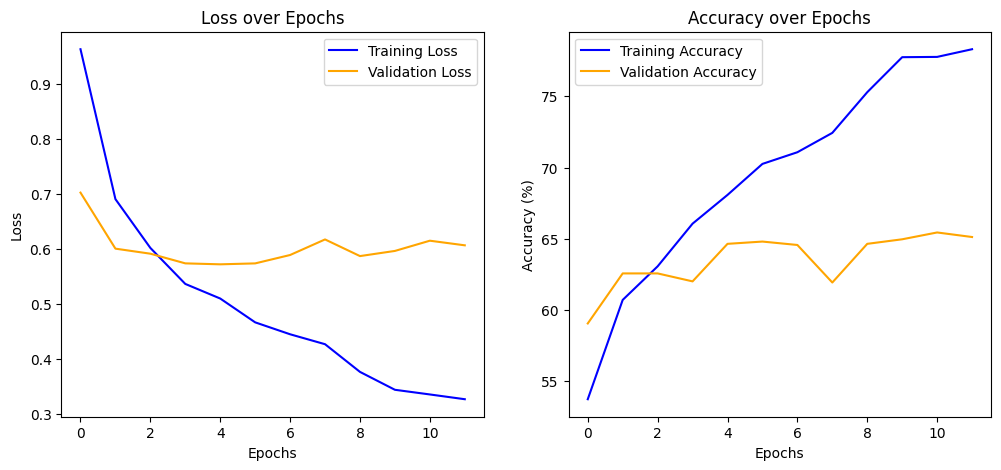

In [ ]:
import os
import shutil
import zipfile
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report

# SECTION 1 EXTRACTION AND SMART PATHS

zip_file_path = '/content/dataset_cleaned.zip'
extraction_target = '/content/dataset'

# Programmatic Unzipping
if os.path.exists(zip_file_path):
    if not os.path.exists(extraction_target):
        print("Extracting archive...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_target)
        print("Extraction complete.")
    else:
        print("Extraction folder already exists. Skipping unzip.")
else:
    raise FileNotFoundError("ERROR Archive not found.")

extracted_items = os.listdir(extraction_target)
if len(extracted_items) == 1 and os.path.isdir(os.path.join(extraction_target, extracted_items[0])):
    data_dir = os.path.join(extraction_target, extracted_items[0])
else:
    data_dir = extraction_target

print(f"Data directory resolved to {data_dir}")

# SECTION 2 DATA CLEANING AND CLASS CONSOLIDATION

trash_folder_path = os.path.join(data_dir, '0_Trash_Bin')
if os.path.exists(trash_folder_path):
    shutil.rmtree(trash_folder_path)
    print("Excluded Trash Data")

# Consolidate visually identical B Vitamins but keep B2 separate
b_folders = ["Vitamin B complex deficiency", "Vitamin B-12 deficiency", "Vitamin B3 deficieny", "Vitamin B9 deficiency"]
target_b = os.path.join(data_dir, "General Vitamin B Deficiency")

if not os.path.exists(target_b):
    os.makedirs(target_b)

for b in b_folders:
    b_path = os.path.join(data_dir, b)
    if os.path.exists(b_path):
        for img_file in os.listdir(b_path):
            shutil.move(os.path.join(b_path, img_file), os.path.join(target_b, img_file))
        os.rmdir(b_path)
        print(f"Merged {b} into General B Deficiency")

# Rename the messy composite class
old_zinc = os.path.join(data_dir, "zinc, iron, biotin, or protein deficiency")
new_zinc = os.path.join(data_dir, "Mineral and Protein Deficiencies")
if os.path.exists(old_zinc):
    os.rename(old_zinc, new_zinc)
    print("Renamed Mineral class for clarity")

# SECTION 3 ADVANCED AUGMENTATION AND SPLITTING

# We load the dataset without transforms first so we can cleanly split it
base_dataset = datasets.ImageFolder(root=data_dir, transform=None)

# Wrapper class to apply different transforms to Train and Test sets
class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        img, label = self.subset[index]
        img = self.transform(img)
        return img, label
    def __len__(self):
        return len(self.subset)

# Advanced Augmentation for Training to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2)
])

# Standard processing for Testing
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_size = int(0.8 * len(base_dataset))
test_size = len(base_dataset) - train_size
train_subset, test_subset = random_split(base_dataset, [train_size, test_size])

train_dataset = DatasetWrapper(train_subset, transform=train_transforms)
test_dataset = DatasetWrapper(test_subset, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(base_dataset.classes)
print(f"Total Active Classes {num_classes}")

# SECTION 4 WEIGHTED LOSS AND ARCHITECTURE UPGRADE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Training on {device}")

# Calculate Class Weights to fix extreme data imbalance
targets = base_dataset.targets
class_counts = np.bincount(targets)
total_samples = len(targets)
class_weights = total_samples / (num_classes * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Upgrade to ResNet50 for deeper feature extraction
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Progressive Unfreezing We freeze early layers and train the deep layers
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

# Add Dropout Regularization to the final classification head
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)
model = model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Learning Rate Scheduler automatically reduces LR if validation loss stalls
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# SECTION 5 THE SMART TRAINING LOOP

num_epochs = 12
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

# Tracking lists for plotting
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

print("Starting Training Loop with Checkpointing")
for epoch in range(num_epochs):

    # TRAINING PHASE
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    # TESTING PHASE
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = test_loss / len(test_loader)
    epoch_val_acc = 100 * correct_test / total_test

    # Track metrics
    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    train_acc_history.append(epoch_train_acc)
    val_acc_history.append(epoch_val_acc)

    # Step the scheduler
    scheduler.step(epoch_val_loss)

    # Model Checkpointing save the best weights
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss {epoch_train_loss:.4f} Acc {epoch_train_acc:.2f}% | Test Loss {epoch_val_loss:.4f} Acc {epoch_val_acc:.2f}%")

print("Training Complete")

# Load best model weights
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/content/dataset/best_vitamin_model.pth')

# SECTION 6 EVALUATION AND GRAPH PLOTTING

print("Generating Final Performance Metrics on Best Checkpoint")
print(classification_report(all_labels, all_preds, target_names=base_dataset.classes, zero_division=0))

# Generate Matplotlib Graphs
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss', color='blue')
plt.plot(val_loss_history, label='Validation Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy', color='blue')
plt.plot(val_acc_history, label='Validation Accuracy', color='orange')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Save the graph so you can download it
graph_path = '/content/dataset/training_metrics_graph.png'
plt.savefig(graph_path)
print(f"Graphs saved successfully to {graph_path}")

Extracting archive...
Extraction complete.
Data directory resolved to /content/dataset/dataset_cleaned
Excluded Trash Data
Merged Vitamin B complex deficiency into General B Deficiency
Merged Vitamin B-12 deficiency into General B Deficiency
Merged Vitamin B3 deficieny into General B Deficiency
Merged Vitamin B9 deficiency into General B Deficiency
Renamed Mineral class for clarity
Total Active Classes 8
Initializing Training on cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


Starting Training Loop with Early Stopping and Checkpointing
Epoch [1/12] Train Loss 0.9789 Acc 54.60% | Test Loss 0.8100 Acc 56.98%
Epoch [2/12] Train Loss 0.6667 Acc 61.15% | Test Loss 0.6440 Acc 62.41%
Epoch [3/12] Train Loss 0.5702 Acc 64.02% | Test Loss 0.6310 Acc 62.89%
Epoch [4/12] Train Loss 0.5416 Acc 67.22% | Test Loss 0.6210 Acc 65.60%
Epoch [5/12] Train Loss 0.4749 Acc 69.04% | Test Loss 0.6964 Acc 64.49%
Notice Validation Loss did not improve. Early Stopping Counter 1/3
Epoch [6/12] Train Loss 0.4783 Acc 69.71% | Test Loss 0.6909 Acc 62.73%
Notice Validation Loss did not improve. Early Stopping Counter 2/3
Epoch [7/12] Train Loss 0.4408 Acc 71.27% | Test Loss 0.6413 Acc 65.92%
Notice Validation Loss did not improve. Early Stopping Counter 3/3

Early Stopping Triggered! The model has started to overfit.
Terminating the training loop early to preserve the best weights.

Training Complete
Generating Final Performance Metrics on Best Checkpoint
                                

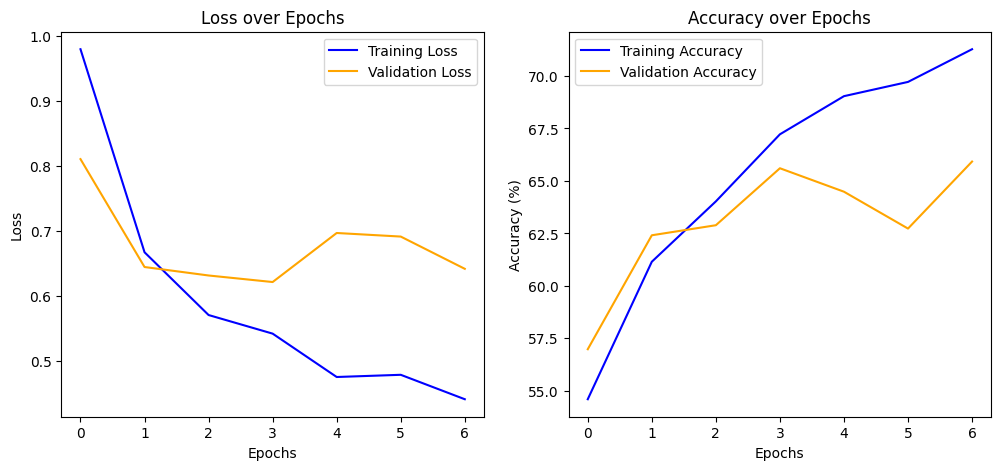

In [ ]:
import os
import shutil
import zipfile
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report

# SECTION 1 EXTRACTION AND SMART PATHS

zip_file_path = '/content/dataset_cleaned.zip'
extraction_target = '/content/dataset'

# Programmatic Unzipping
if os.path.exists(zip_file_path):
    if not os.path.exists(extraction_target):
        print("Extracting archive...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_target)
        print("Extraction complete.")
    else:
        print("Extraction folder already exists. Skipping unzip.")
else:
    raise FileNotFoundError("ERROR Archive not found.")

extracted_items = os.listdir(extraction_target)
if len(extracted_items) == 1 and os.path.isdir(os.path.join(extraction_target, extracted_items[0])):
    data_dir = os.path.join(extraction_target, extracted_items[0])
else:
    data_dir = extraction_target

print(f"Data directory resolved to {data_dir}")

# SECTION 2 DATA CLEANING AND CLASS CONSOLIDATION

trash_folder_path = os.path.join(data_dir, '0_Trash_Bin')
if os.path.exists(trash_folder_path):
    shutil.rmtree(trash_folder_path)
    print("Excluded Trash Data")

# Consolidate visually identical B Vitamins but keep B2 separate
b_folders = ["Vitamin B complex deficiency", "Vitamin B-12 deficiency", "Vitamin B3 deficieny", "Vitamin B9 deficiency"]
target_b = os.path.join(data_dir, "General Vitamin B Deficiency")

if not os.path.exists(target_b):
    os.makedirs(target_b)

for b in b_folders:
    b_path = os.path.join(data_dir, b)
    if os.path.exists(b_path):
        for img_file in os.listdir(b_path):
            shutil.move(os.path.join(b_path, img_file), os.path.join(target_b, img_file))
        os.rmdir(b_path)
        print(f"Merged {b} into General B Deficiency")

# Rename the messy composite class
old_zinc = os.path.join(data_dir, "zinc, iron, biotin, or protein deficiency")
new_zinc = os.path.join(data_dir, "Mineral and Protein Deficiencies")
if os.path.exists(old_zinc):
    os.rename(old_zinc, new_zinc)
    print("Renamed Mineral class for clarity")

# SECTION 3 ADVANCED AUGMENTATION AND SPLITTING

base_dataset = datasets.ImageFolder(root=data_dir, transform=None)

class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        img, label = self.subset[index]
        img = self.transform(img)
        return img, label
    def __len__(self):
        return len(self.subset)

# Advanced Augmentation for Training to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2)
])

# Standard processing for Testing
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_size = int(0.8 * len(base_dataset))
test_size = len(base_dataset) - train_size
train_subset, test_subset = random_split(base_dataset, [train_size, test_size])

train_dataset = DatasetWrapper(train_subset, transform=train_transforms)
test_dataset = DatasetWrapper(test_subset, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(base_dataset.classes)
print(f"Total Active Classes {num_classes}")

# SECTION 4 WEIGHTED LOSS AND ARCHITECTURE UPGRADE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Initializing Training on {device}")

# Calculate Class Weights to fix extreme data imbalance
targets = base_dataset.targets
class_counts = np.bincount(targets)
total_samples = len(targets)
class_weights = total_samples / (num_classes * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Upgrade to ResNet50 for deeper feature extraction
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Progressive Unfreezing We freeze early layers and train the deep layers
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

# Add Dropout Regularization to the final classification head
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)
model = model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# SECTION 5 THE SMART TRAINING LOOP WITH EARLY STOPPING

num_epochs = 12
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

# Early Stopping Variables
best_val_loss = float('inf')
early_stopping_patience = 3
epochs_no_improve = 0

# Tracking lists for plotting
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

print("Starting Training Loop with Early Stopping and Checkpointing")
for epoch in range(num_epochs):

    # TRAINING PHASE
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    # TESTING PHASE
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = test_loss / len(test_loader)
    epoch_val_acc = 100 * correct_test / total_test

    # Track metrics
    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    train_acc_history.append(epoch_train_acc)
    val_acc_history.append(epoch_val_acc)

    # Step the scheduler
    scheduler.step(epoch_val_loss)

    # Model Checkpointing save the best weights based on accuracy
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss {epoch_train_loss:.4f} Acc {epoch_train_acc:.2f}% | Test Loss {epoch_val_loss:.4f} Acc {epoch_val_acc:.2f}%")

    # EARLY STOPPING LOGIC
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Notice Validation Loss did not improve. Early Stopping Counter {epochs_no_improve}/{early_stopping_patience}")

    if epochs_no_improve >= early_stopping_patience:
        print("\nEarly Stopping Triggered! The model has started to overfit.")
        print("Terminating the training loop early to preserve the best weights.")
        break

print("\nTraining Complete")

# Load best model weights
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/content/dataset/best_vitamin_model.pth')

# SECTION 6 EVALUATION AND GRAPH PLOTTING

print("Generating Final Performance Metrics on Best Checkpoint")
print(classification_report(all_labels, all_preds, target_names=base_dataset.classes, zero_division=0))

# Generate Matplotlib Graphs
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss', color='blue')
plt.plot(val_loss_history, label='Validation Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy', color='blue')
plt.plot(val_acc_history, label='Validation Accuracy', color='orange')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Save the graph so you can download it
graph_path = '/content/dataset/training_metrics_graph.png'
plt.savefig(graph_path)
print(f"Graphs saved successfully to {graph_path}")